modelo clasificador de pam50 sobre la base de datos tcga-brca

## configuracion del entorno django


In [76]:
import os
import sys

# directorio de la app
DJANGO_APP_PATH = "/home/ph0/MBIO/TFM/src/app"
sys.path.insert(0, DJANGO_APP_PATH)

# credenciales de la bd
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "project.settings")
os.environ.setdefault("POSTGRES_HOST", "localhost")
os.environ.setdefault("POSTGRES_DB", "tfg_db")
os.environ.setdefault("POSTGRES_USER", "postgres")
os.environ.setdefault("POSTGRES_PASSWORD", "password")
os.environ.setdefault("POSTGRES_PORT", "5432")

# orm sincrono
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django
django.setup()
print("Django OK:", django.__version__)


Django OK: 6.0.5


## carga de datos desde la bd


In [77]:
import pandas as pd
import numpy as np

from core.models import TCGACase, TCGAFile, TCGAExpressionRecord

# casos con etiqueta pam50
cases_qs = TCGACase.objects.exclude(molecular_subtype="").values("id", "case_id", "molecular_subtype")
df_cases = pd.DataFrame.from_records(cases_qs)
print(f"Casos con PAM50: {len(df_cases)}")
print(df_cases["molecular_subtype"].value_counts())

Casos con PAM50: 843
molecular_subtype
LumA      375
LumB      170
Basal     124
Normal    116
Her2       58
Name: count, dtype: int64


In [78]:
# mapear caso a fichero
# solo ficheros de expresion

file_case_rows = list(
    TCGAFile.objects
    .filter(
        data_type="Gene Expression Quantification",
        cases__molecular_subtype__gt="",  # solo casos etiquetados
    )
    .values("id", "file_id", "cases__id", "cases__molecular_subtype")
)

if not file_case_rows:
    raise RuntimeError("No se encontraron ficheros con casos etiquetados PAM50")

df_file_case = pd.DataFrame.from_records(file_case_rows)
df_file_case.columns = ["file_pk", "file_id", "case_pk", "molecular_subtype"]
# un fichero por caso
df_file_case = df_file_case.drop_duplicates(subset="case_pk")
print(f"Ficheros con caso etiquetado: {len(df_file_case)}")
print(df_file_case["molecular_subtype"].value_counts())


Ficheros con caso etiquetado: 360
molecular_subtype
LumA      166
LumB       63
Normal     54
Basal      50
Her2       27
Name: count, dtype: int64


In [79]:
# cargar expresion
# solo protein_coding
import time

file_pks = df_file_case["file_pk"].tolist()

print(f"Cargando expresión de {len(file_pks)} ficheros (solo protein_coding)")
t0 = time.time()

expr_qs = (
    TCGAExpressionRecord.objects
    .filter(
        tcga_file_id__in=file_pks,
        gene_type="protein_coding",
    )
    .values("tcga_file_id", "gene_name", "tpm_unstranded")
)

df_expr = pd.DataFrame.from_records(expr_qs)
print(f"Filas cargadas: {len(df_expr):,}  ({time.time()-t0:.1f}s)")
print(df_expr.head())

Cargando expresión de 360 ficheros (solo protein_coding)
Filas cargadas: 4,411,602  (8.6s)
   tcga_file_id gene_name  tpm_unstranded
0           501    TSPAN6         51.4242
1           501      TNMD        112.2585
2           501      DPM1         65.4030
3           501     SCYL3          8.2410
4           501  C1orf112          3.7091


## construccion de la matriz muestras x genes


In [80]:
# pivotar
df_matrix = df_expr.pivot_table(
    index="tcga_file_id",
    columns="gene_name",
    values="tpm_unstranded",
    aggfunc="first",
)
print(f"Matriz: {df_matrix.shape[0]} muestras x {df_matrix.shape[1]} genes")

# etiqueta pam50
file_pk_to_subtype = df_file_case.set_index("file_pk")["molecular_subtype"].to_dict()
df_matrix["label"] = df_matrix.index.map(file_pk_to_subtype)
df_matrix = df_matrix.dropna(subset=["label"])
print(f"Muestras con etiqueta: {len(df_matrix)}")
print(df_matrix["label"].value_counts())

Matriz: 221 muestras x 19938 genes
Muestras con etiqueta: 221
label
LumA      106
LumB       39
Basal      31
Normal     30
Her2       15
Name: count, dtype: int64


In [81]:
# separar features y target
y = df_matrix["label"].values
X = df_matrix.drop(columns=["label"]).values.astype(np.float32)

# rellenar nan
X = np.nan_to_num(X, nan=0.0)

# log1p
X = np.log1p(X)

gene_names = df_matrix.drop(columns=["label"]).columns.tolist()
print(f"X: {X.shape}, y: {y.shape}")
print(f"Clases: {sorted(set(y))}")

X: (221, 19938), y: (221,)
Clases: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']


## seleccion de features, varianza


In [82]:

# top genes variables
variances = X.var(axis=0)
top_idx = np.argsort(variances)[::-1][:3000]
X_sel = X[:, top_idx]
gene_names_sel = [gene_names[i] for i in top_idx]

print(f"Features seleccionados: {X_sel.shape[1]}")

Features seleccionados: 3000


## pca, visualizacion


Assigning font /F1 (subset 1) = FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0)
Assigning font /F2 (subset 0) = FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0)
Embedding font FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0):0.
Writing TrueType font.
Embedding font FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0):1.
Writing TrueType font.


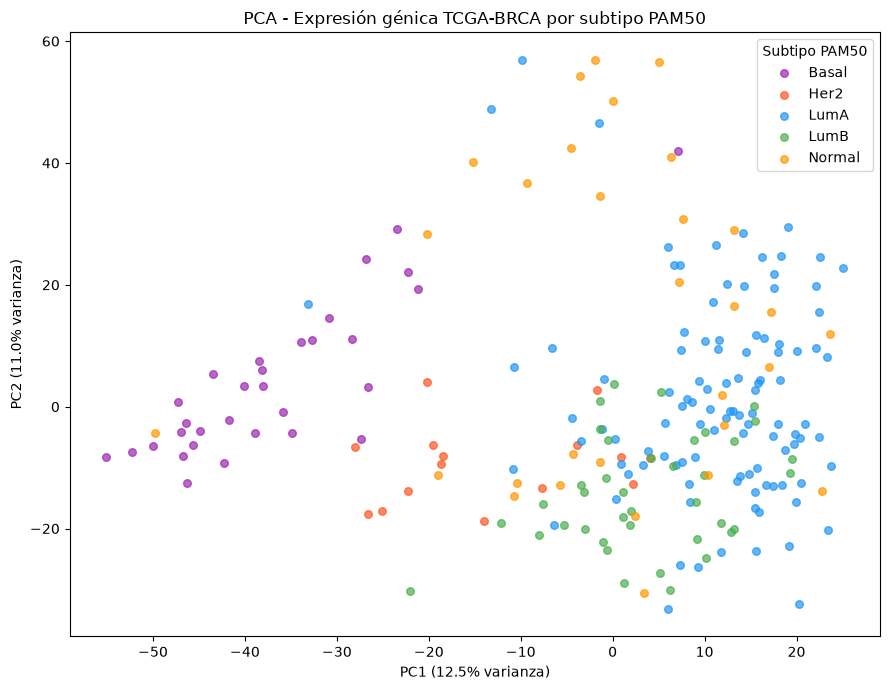

Varianza explicada PC1+PC2: 23.5%


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["subtipo"] = y

palette = {"LumA": "#2196F3", "LumB": "#4CAF50", "Her2": "#FF5722",
           "Basal": "#9C27B0", "Normal": "#FF9800"}

fig, ax = plt.subplots(figsize=(9, 7))
for subtype, group in df_pca.groupby("subtipo"):
    ax.scatter(group["PC1"], group["PC2"], label=subtype,
               color=palette.get(subtype, "gray"), alpha=0.7, s=30)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("PCA - Expresión génica TCGA-BRCA por subtipo PAM50")
ax.legend(title="Subtipo PAM50")
plt.tight_layout()
plt.savefig("../tex/figures/pca_pam50.pdf", dpi=150)
plt.show()
print(f"Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

## clasificacion supervisada, rf


In [84]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 176 | Test: 45


In [85]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
y_proba = rf.predict_proba(X_test)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
report = classification_report(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"F1 macro : {f1_macro:.4f}")
print(f"F1 weighted: {f1_weighted:.4f}")
print(f"AUC macro (ovr) : {auc_macro:.4f}")
print()
print(report)

Accuracy : 0.6889
F1 macro : 0.6333
F1 weighted: 0.6685
AUC macro (ovr) : 0.8575

              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         6
        Her2       0.60      1.00      0.75         3
        LumA       0.83      0.68      0.75        22
        LumB       0.54      0.88      0.67         8
      Normal       0.00      0.00      0.00         6

    accuracy                           0.69        45
   macro avg       0.59      0.71      0.63        45
weighted avg       0.68      0.69      0.67        45



## confusion matrix


locator: <matplotlib.ticker.AutoLocator object at 0x787168a0ac30>
Assigning font /F1 (subset 0) = FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0)
Embedding font FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0):0.
Writing TrueType font.


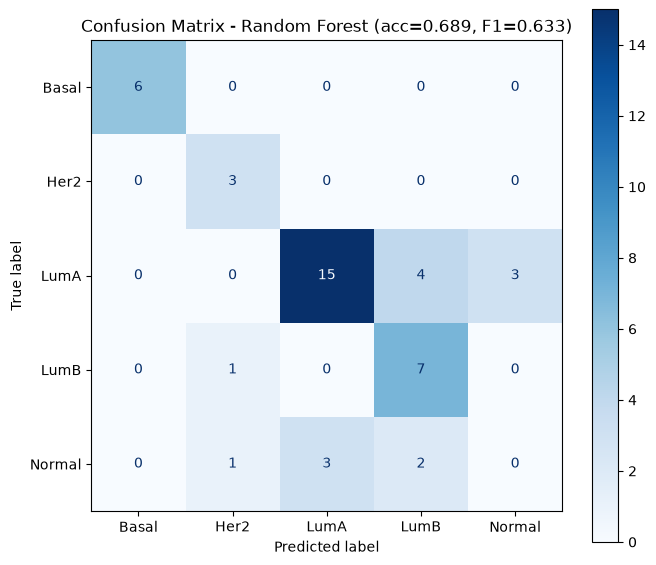

In [86]:
labels = sorted(set(y))
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Confusion Matrix - Random Forest (acc={acc:.3f}, F1={f1_macro:.3f})")
plt.tight_layout()
plt.savefig("../tex/figures/confusion_matrix_rf.pdf", dpi=150)
plt.show()

Assigning font /F1 (subset 0) = FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0)
Embedding font FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0):0.
Writing TrueType font.


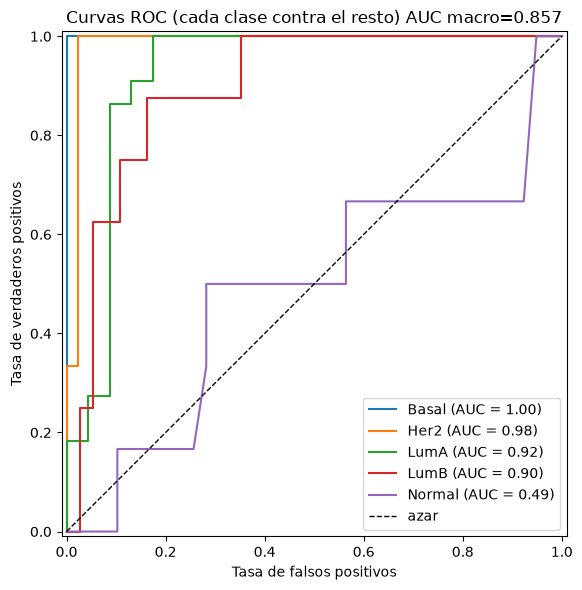

In [87]:
# curva roc (cada subtipo contra el resto)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

classes = np.array(labels)
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(7, 6))
for i, clase in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_proba[:, i], name=f"{clase}", ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="azar")
ax.set_title(f"Curvas ROC (cada clase contra el resto) AUC macro={auc_macro:.3f}")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../tex/figures/roc_curves_rf.pdf", dpi=150)
plt.show()


## genes mas relevantes


/tmp/ipykernel_116439/307695224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="gene", ax=ax, palette="viridis")
Assigning font /F1 (subset 0) = FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0)
Embedding font FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0):0.
Writing TrueType font.


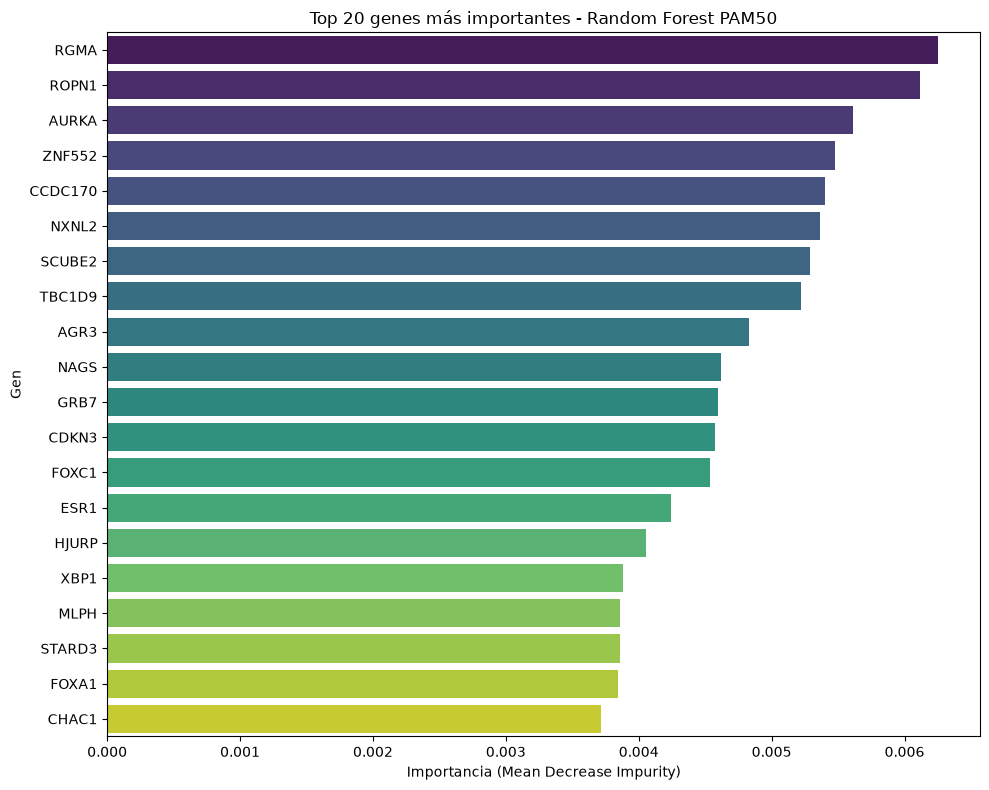

   gene  importance  rank
   RGMA    0.006255     1
  ROPN1    0.006114     2
  AURKA    0.005610     3
 ZNF552    0.005476     4
CCDC170    0.005400     5
  NXNL2    0.005361     6
 SCUBE2    0.005291     7
 TBC1D9    0.005221     8
   AGR3    0.004831     9
   NAGS    0.004619    10
   GRB7    0.004599    11
  CDKN3    0.004572    12
  FOXC1    0.004536    13
   ESR1    0.004240    14
  HJURP    0.004054    15
   XBP1    0.003885    16
   MLPH    0.003862    17
 STARD3    0.003855    18
  FOXA1    0.003845    19
  CHAC1    0.003715    20


In [88]:
importances = rf.feature_importances_
top_n = 20
top_idx_imp = np.argsort(importances)[::-1][:top_n]

df_imp = pd.DataFrame({
    "gene": [gene_names_sel[i] for i in top_idx_imp],
    "importance": importances[top_idx_imp],
    "rank": range(1, top_n + 1),
})

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_imp, x="importance", y="gene", ax=ax, palette="viridis")
ax.set_title(f"Top {top_n} genes más importantes - Random Forest PAM50")
ax.set_xlabel("Importancia (Mean Decrease Impurity)")
ax.set_ylabel("Gen")
plt.tight_layout()
plt.savefig("../tex/figures/feature_importances_rf.pdf", dpi=150)
plt.show()
print(df_imp.to_string(index=False))

## validacion cruzada


In [89]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_sel, y, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"CV F1 macro (5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Scores por fold: {cv_scores.round(4)}")

CV F1 macro (5-fold): 0.7014 +/- 0.1079
Scores por fold: [0.713  0.618  0.5446 0.8303 0.8011]


## guardar resultados en bbdd


In [90]:
from core.models import MLModelRun, MLGeneImportance, HGNCGene

# guardar run
run = MLModelRun.objects.create(
    algorithm="RandomForestClassifier",
    n_samples=len(X_sel),
    n_features=X_sel.shape[1],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    hyperparams={
        "n_estimators": 300,
        "max_depth": None,
        "class_weight": "balanced",
    },
    accuracy=float(acc),
    f1_macro=float(f1_macro),
    f1_weighted=float(f1_weighted),
    confusion_matrix=cm.tolist(),
    class_labels=labels,
    classification_report=report,
    notes=f"CV F1 macro 5-fold: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}",
)
print(f"MLModelRun creado: id={run.id}")

# guardar genes importantes
hgnc_by_symbol = {
    g.symbol: g
    for g in HGNCGene.objects.filter(symbol__in=df_imp["gene"].tolist())
}

gene_imp_objects = [
    MLGeneImportance(
        run=run,
        gene_name=row["gene"],
        gene_id=hgnc_by_symbol.get(row["gene"], None) and hgnc_by_symbol[row["gene"]].ensembl_gene_id or "",
        importance=float(row["importance"]),
        rank=int(row["rank"]),
        hgnc_gene=hgnc_by_symbol.get(row["gene"]),
    )
    for _, row in df_imp.iterrows()
]
MLGeneImportance.objects.bulk_create(gene_imp_objects)
print(f"MLGeneImportance creados: {len(gene_imp_objects)}")

MLModelRun creado: id=10
MLGeneImportance creados: 20


In [91]:
# actualizar subtipo
from core.models import TCGACase

# predicciones test
# file_pk a case
file_pk_to_case_id = df_file_case.set_index("file_pk")["case_pk"].to_dict()

# predecir todo
y_pred_all = rf.predict(X_sel)
file_pks_matrix = df_matrix.index.tolist()

cases_to_update = []
for file_pk, pred in zip(file_pks_matrix, y_pred_all):
    case_pk = file_pk_to_case_id.get(file_pk)
    if case_pk:
        cases_to_update.append(TCGACase(id=case_pk, predicted_subtype=pred))

TCGACase.objects.bulk_update(cases_to_update, ["predicted_subtype"], batch_size=200)
print(f"TCGACase actualizados con predicted_subtype: {len(cases_to_update)}")

TCGACase actualizados con predicted_subtype: 221


## resumen final


In [92]:
print("RESUMEN CLASIFICACIÓN PAM50 TCGA-BRCA\n")
print(f"Muestras totales: {len(X_sel)}")
print(f"Genes (features): {X_sel.shape[1]}")
print(f"Train / Pruebas: {len(X_train)} / {len(X_test)}")
print(f"Algoritmo: RandomForestClassifier (300 trees, balanced)")
print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 weighted: {f1_weighted:.4f}")
print(f"CV F1 macro 5-fold: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print()
print("Top 10 genes más importantes:")
print(df_imp.head(10)[["rank", "gene", "importance"]].to_string(index=False))

RESUMEN CLASIFICACIÓN PAM50 TCGA-BRCA

Muestras totales: 221
Genes (features): 3000
Train / Pruebas: 176 / 45
Algoritmo: RandomForestClassifier (300 trees, balanced)
Accuracy: 0.6889
F1 macro: 0.6333
F1 weighted: 0.6685
CV F1 macro 5-fold: 0.7014 +/- 0.1079

Top 10 genes más importantes:
 rank    gene  importance
    1    RGMA    0.006255
    2   ROPN1    0.006114
    3   AURKA    0.005610
    4  ZNF552    0.005476
    5 CCDC170    0.005400
    6   NXNL2    0.005361
    7  SCUBE2    0.005291
    8  TBC1D9    0.005221
    9    AGR3    0.004831
   10    NAGS    0.004619
